# Análise Preditiva e Evolução da Matriz Elétrica Brasileira

**Autor:** André Luis Chaves Madeira  
**Curso:** Tecnólogo em Ciência de Dados e Business Intelligence — UCP 2026

### **Estrutura do Projeto (Metodologia KDD)**

| Etapa KDD | Processos Realizados | Descrição Técnica |
|:----------|:---------------------|:------------------|
| **1. Seleção** | Ingestão de Dados | Configuração do ambiente e coleta da base histórica da IEA (2015-2025). |
| **2. Pré-processamento** | Limpeza e Filtragem | Tratamento de nulos, filtragem geográfica (Brasil) e normalização temporal. |
| **3. Transformação** | Análise Estatística | Decomposição STL (Tendência/Sazonalidade) e Testes de Estacionariedade (ADF). |
| **4. Mineração de Dados** | Modelagem Preditiva | Implementação e treinamento dos algoritmos estocásticos (SARIMA) e de crescimento (Prophet). |
| **5. Interpretação/Avaliação**| Validação e Projeção | Análise de métricas (MAE/RMSE/MAPE), cálculo de CAGR e projeções para 2026. |

## ETAPA 0 - EXIBIÇÃO DO DATASET INICIAL

In [ ]:
# ==============================================================================
# EXIBIÇÃO DO DATASET INICIAL
# # Visão geral da base bruta antes do pré-processamento
# ==============================================================================

import pandas as pd

# URL da base de dados
URL = "https://raw.githubusercontent.com/andrelcmadeira/Pratica_em_ciencia_de_Dados/refs/heads/main/base_completa_iea.csv"
df_raw = pd.read_csv(URL, sep=";")

print("1. Primeiras 5 linhas:")
display(df_raw.head())

print("\n2. Contagem de linhas e colunas:")
print(f"Linhas: {df_raw.shape[0]} | Colunas: {df_raw.shape[1]}")

print(f"\n3. Países disponíveis ({len(df_raw['COUNTRY'].unique())} países):")
print(df_raw['COUNTRY'].unique())

print(f"\n4. Produtos disponíveis ({len(df_raw['PRODUCT'].unique())} produtos):")
print(df_raw['PRODUCT'].unique())

print("\n5. Colunas com valores nulos/vazios:")
print(df_raw.isnull().sum())

print("\n6. Tipos de dado (informações técnicas):")
print(df_raw.info())

1. Primeiras 5 linhas:


,COUNTRY,CODE_TIME,TIME,YEAR,MONTH,MONTH_NAME,PRODUCT,VALUE,DISPLAY_ORDER,yearToDate,previousYearToDate,share
0,Argentina,JAN2015,January 2015,2015,1,January,Hydro,2519.945,1,2519.945,NaN,0.209872
1,Argentina,JAN2015,January 2015,2015,1,January,Wind,51.294,2,51.294,NaN,0.004272
2,Argentina,JAN2015,January 2015,2015,1,January,Solar,1.511,3,1.511,NaN,0.000126
3,Argentina,JAN2015,January 2015,2015,1,January,Geothermal,0.000,4,0.000,NaN,0.000000
4,Argentina,JAN2015,January 2015,2015,1,January,Other renewables,0.000,5,0.000,NaN,0.000000



2. Contagem de linhas e colunas:
Linhas: 183068 | Colunas: 12

3. Países disponíveis (43 países):
['Argentina' 'Australia' 'Austria' 'Belgium' 'Brazil' 'Bulgaria' 'Canada'
 'Chile' 'Greece' 'Hungary' 'IEA Total' 'Iceland' 'India' 'Ireland'
 'Italy' 'Japan' 'Korea' 'Latvia' 'Lithuania' 'Luxembourg' 'Malta'
 'Mexico' 'Netherlands' 'New Zealand' 'North Macedonia' 'Norway'
 'OECD Americas' 'OECD Asia Oceania' 'OECD Europe' 'OECD Total'
 "People's Republic of China" 'Poland' 'Portugal' 'Republic of Turkiye'
 'Romania' 'Serbia' 'Slovak Republic' 'Slovenia' 'Spain' 'Sweden'
 'Switzerland' 'United Kingdom' 'United States']

4. Produtos disponíveis (27 produtos):
['Hydro' 'Wind' 'Solar' 'Geothermal' 'Other renewables' 'Nuclear'
 'Total combustible fuels' 'Coal' 'Oil' 'Natural gas'
 'Combustible renewables' 'Other combustible non-renewables'
 'Net electricity production' 'Total imports' 'Total exports'
 'Electricity supplied' 'Used for pumped storage' 'Distribution losses'
 'Final consumption' 

# ETAPA 1

In [1]:
# ==============================================================================
# ETAPA 1: SELEÇÃO E CONFIGURAÇÃO
# ==============================================================================

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

# --- PARÂMETROS E PALETA DE CORES ---
CORES = {
    "Hydro": "#1f77b4", "Wind": "#17becf", "Solar": "#f5a623",
    "Combustible renewables": "#2ca02c", "Geothermal": "#8B4513",
    "Other renewables": "#98df8a", "Natural gas": "#8c564b",
    "Coal": "#555555", "Oil": "#d62728", "Nuclear": "#9467bd",
    "Other combustible non-renewables": "#c5b0d5",
}

FONTES_RENOVAVEIS     = ["Hydro","Wind","Solar","Combustible renewables","Geothermal","Other renewables"]
FONTES_NAO_RENOVAVEIS = ["Natural gas","Coal","Oil","Nuclear","Other combustible non-renewables"]
FONTES_PRINCIPAIS     = FONTES_RENOVAVEIS + FONTES_NAO_RENOVAVEIS

# Estilo visual para os gráficos
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "grid.linestyle": "--",
    "axes.titlesize": 13, "axes.labelsize": 11, "legend.frameon": True
})

# --- INGESTÃO E VISÃO GERAL ---
URL = "https://raw.githubusercontent.com/andrelcmadeira/Pratica_em_ciencia_de_Dados/refs/heads/main/base_completa_iea.csv"
df_raw = pd.read_csv(URL, sep=";")


c:\Users\andre\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# ETAPA 2

In [4]:
# ==============================================================================
# ETAPA 2: PRÉ-PROCESSAMENTO
# ==============================================================================

# Estruturação da Data para o índice temporal
df_raw["Date"] = pd.to_datetime(df_raw[["YEAR", "MONTH"]].assign(day=1))

# Filtro: Brasil, período 2015-2025
filtro = (
    (df_raw["COUNTRY"].str.strip() == "Brazil") &
    (df_raw["Date"] >= "2015-01-01") &
    (df_raw["Date"] <= "2025-12-31") &
    (df_raw["PRODUCT"].isin(FONTES_PRINCIPAIS))
)
data_filt = df_raw[filtro].copy()

# --- Criação de colunas auxiliares necessárias para a EDA ---
data_filt['Ano'] = data_filt['Date'].dt.year
data_filt['Categoria'] = data_filt['PRODUCT'].apply(lambda x: 'Renovável' if x in FONTES_RENOVAVEIS else 'Não Renovável')

# Criação das séries temporais para Solar e Wind
serie_solar = data_filt[data_filt['PRODUCT'] == 'Solar'].groupby('Date')['VALUE'].sum().sort_index()
serie_wind = data_filt[data_filt['PRODUCT'] == 'Wind'].groupby('Date')['VALUE'].sum().sort_index()

print(f"Base filtrada com sucesso. Período analisado: {serie_solar.index.min().year} a {serie_solar.index.max().year}")
print(f"Colunas auxiliares 'Ano' e 'Categoria' adicionadas para a análise exploratória.")

Base filtrada com sucesso. Período analisado: 2015 a 2025
Colunas auxiliares 'Ano' e 'Categoria' adicionadas para a análise exploratória.


Visão geral da base filtrada para o Brasil

In [5]:
print('--- VISÃO GERAL DA BASE FILTRADA (BRASIL 2015-2025) ---')

print('\n1. Primeiras 5 linhas do dataset filtrado:')
display(data_filt.head())

print('\nÚltimas 5 linhas do dataset filtrado:')
display(data_filt.tail())


print('\n2. Contagem de linhas e colunas (Base Filtrada):')
print(f'Linhas: {data_filt.shape[0]} | Colunas: {data_filt.shape[1]}')

print('\n3. Produtos remanescentes na análise:')
print(data_filt['PRODUCT'].unique())

print('\n4. Colunas com valores nulos/vazios na base filtrada:')
print(data_filt.isnull().sum())

print('\n5. Informações técnicas (Dtypes):')
print(data_filt.info())

--- VISÃO GERAL DA BASE FILTRADA (BRASIL 2015-2025) ---

1. Primeiras 5 linhas do dataset filtrado:


,COUNTRY,CODE_TIME,TIME,YEAR,MONTH,MONTH_NAME,PRODUCT,VALUE,DISPLAY_ORDER,yearToDate,previousYearToDate,share,Date,Ano,Categoria
16931,Brazil,JAN2015,January 2015,2015,1,January,Hydro,34343.374,1,34343.374,NaN,0.681045,2015-01-01,2015,Renovável
16932,Brazil,JAN2015,January 2015,2015,1,January,Wind,1543.120,2,1543.120,NaN,0.030601,2015-01-01,2015,Renovável
16933,Brazil,JAN2015,January 2015,2015,1,January,Solar,2.613,3,2.613,NaN,0.000052,2015-01-01,2015,Renovável
16934,Brazil,JAN2015,January 2015,2015,1,January,Geothermal,0.000,4,0.000,NaN,0.000000,2015-01-01,2015,Renovável
16935,Brazil,JAN2015,January 2015,2015,1,January,Other renewables,0.000,5,0.000,NaN,0.000000,2015-01-01,2015,Renovável



Últimas 5 linhas do dataset filtrado:


,COUNTRY,CODE_TIME,TIME,YEAR,MONTH,MONTH_NAME,PRODUCT,VALUE,DISPLAY_ORDER,yearToDate,previousYearToDate,share,Date,Ano,Categoria
19906,Brazil,DEC2025,December 2025,2025,12,December,Coal,1478.125388,8,17602.334067,15825.919872,0.023013,2025-12-01,2025,Não Renovável
19907,Brazil,DEC2025,December 2025,2025,12,December,Oil,590.426108,9,7225.578683,11636.651044,0.009192,2025-12-01,2025,Não Renovável
19908,Brazil,DEC2025,December 2025,2025,12,December,Natural gas,6555.497294,10,69405.460182,56951.951587,0.102062,2025-12-01,2025,Não Renovável
19909,Brazil,DEC2025,December 2025,2025,12,December,Combustible renewables,2630.527117,11,54408.817507,53957.935762,0.040954,2025-12-01,2025,Renovável
19910,Brazil,DEC2025,December 2025,2025,12,December,Other combustible non-renewables,89.181403,12,1070.176836,1070.176836,0.001388,2025-12-01,2025,Não Renovável



2. Contagem de linhas e colunas (Base Filtrada):
Linhas: 1356 | Colunas: 15

3. Produtos remanescentes na análise:
['Hydro' 'Wind' 'Solar' 'Geothermal' 'Other renewables' 'Nuclear' 'Coal'
 'Oil' 'Natural gas' 'Combustible renewables'
 'Other combustible non-renewables']

4. Colunas com valores nulos/vazios na base filtrada:
COUNTRY                 0
CODE_TIME               0
TIME                    0
YEAR                    0
MONTH                   0
MONTH_NAME              0
PRODUCT                 0
VALUE                   0
DISPLAY_ORDER           0
yearToDate              0
previousYearToDate    132
share                   0
Date                    0
Ano                     0
Categoria               0
dtype: int64

5. Informações técnicas (Dtypes):
<class 'pandas.core.frame.DataFrame'>
Index: 1356 entries, 16931 to 19910
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   COUNTRY    

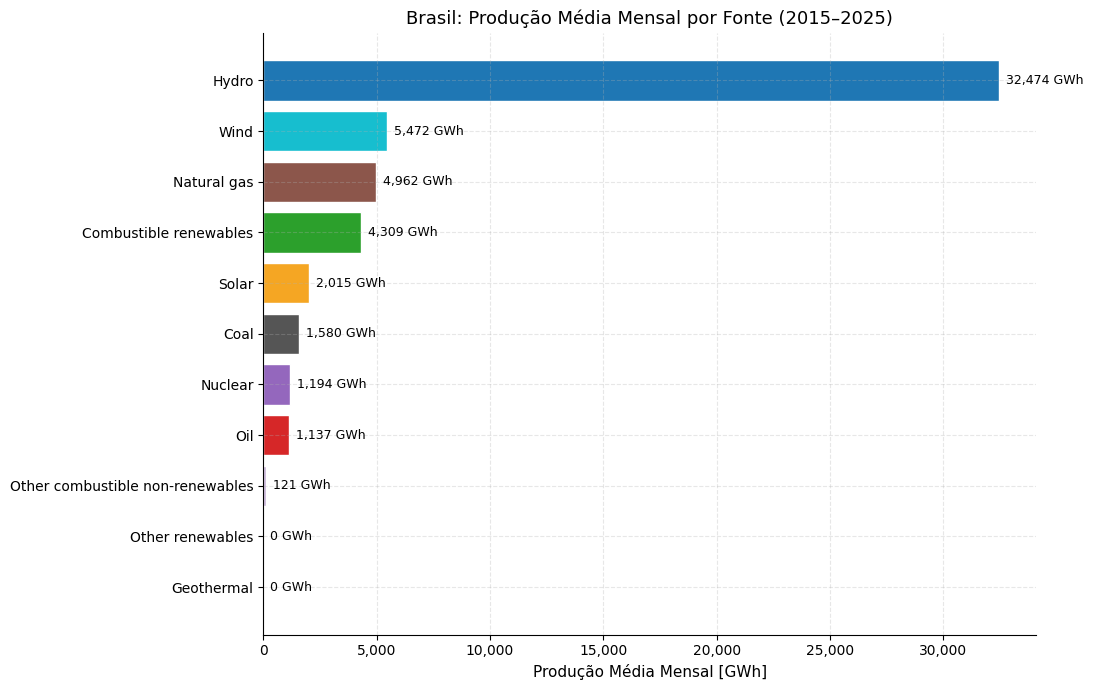

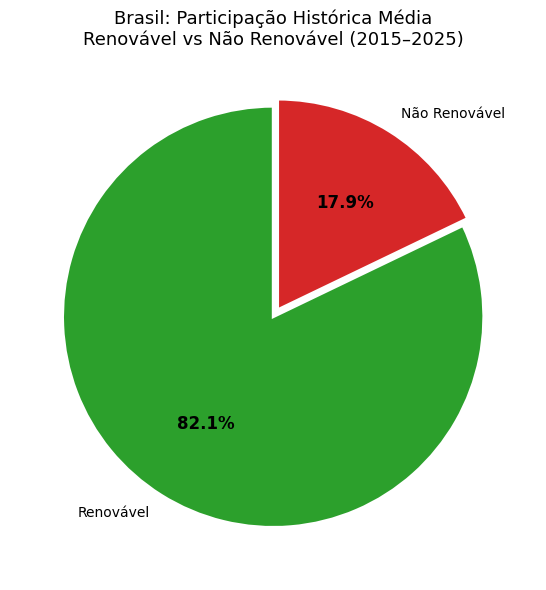

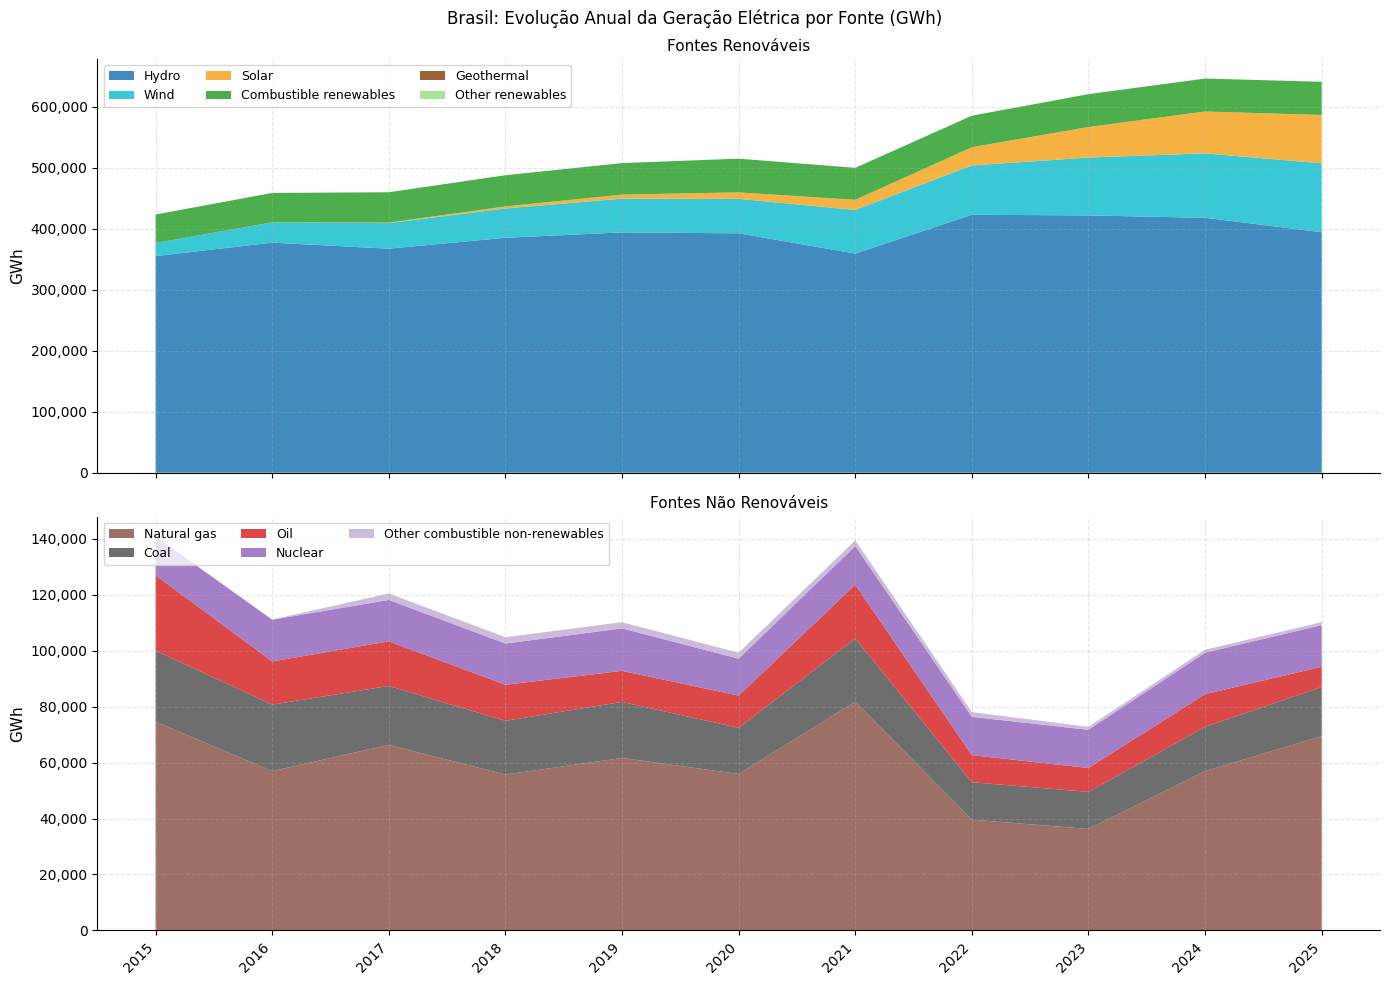

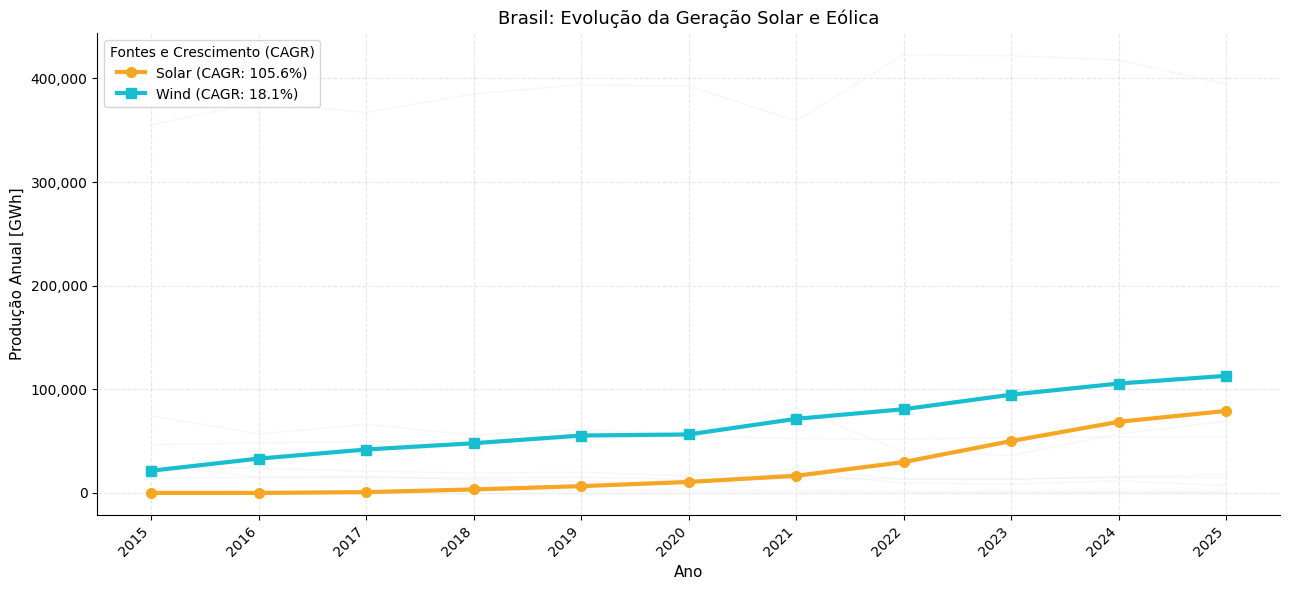

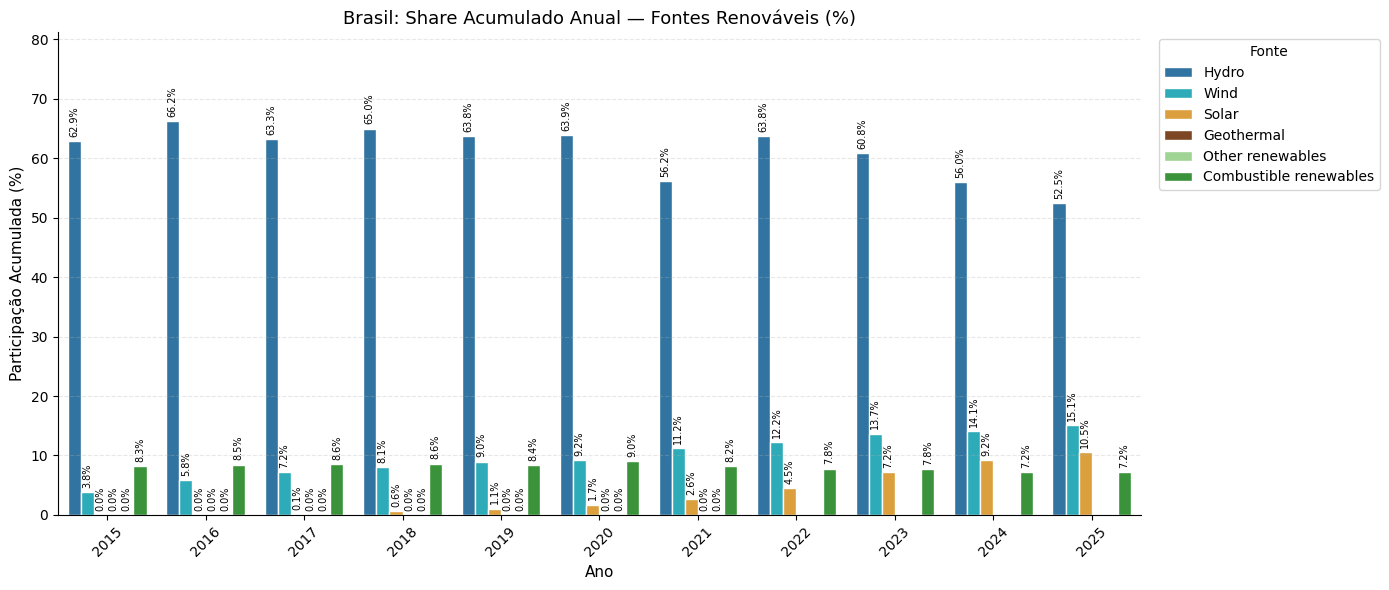

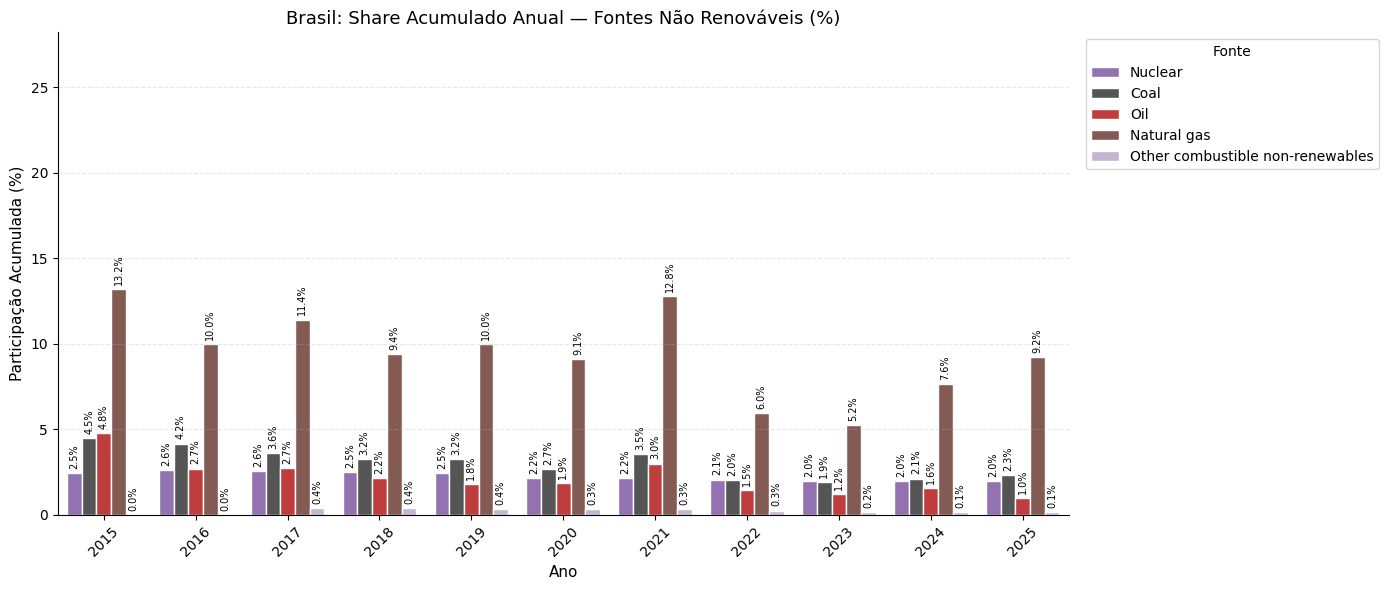

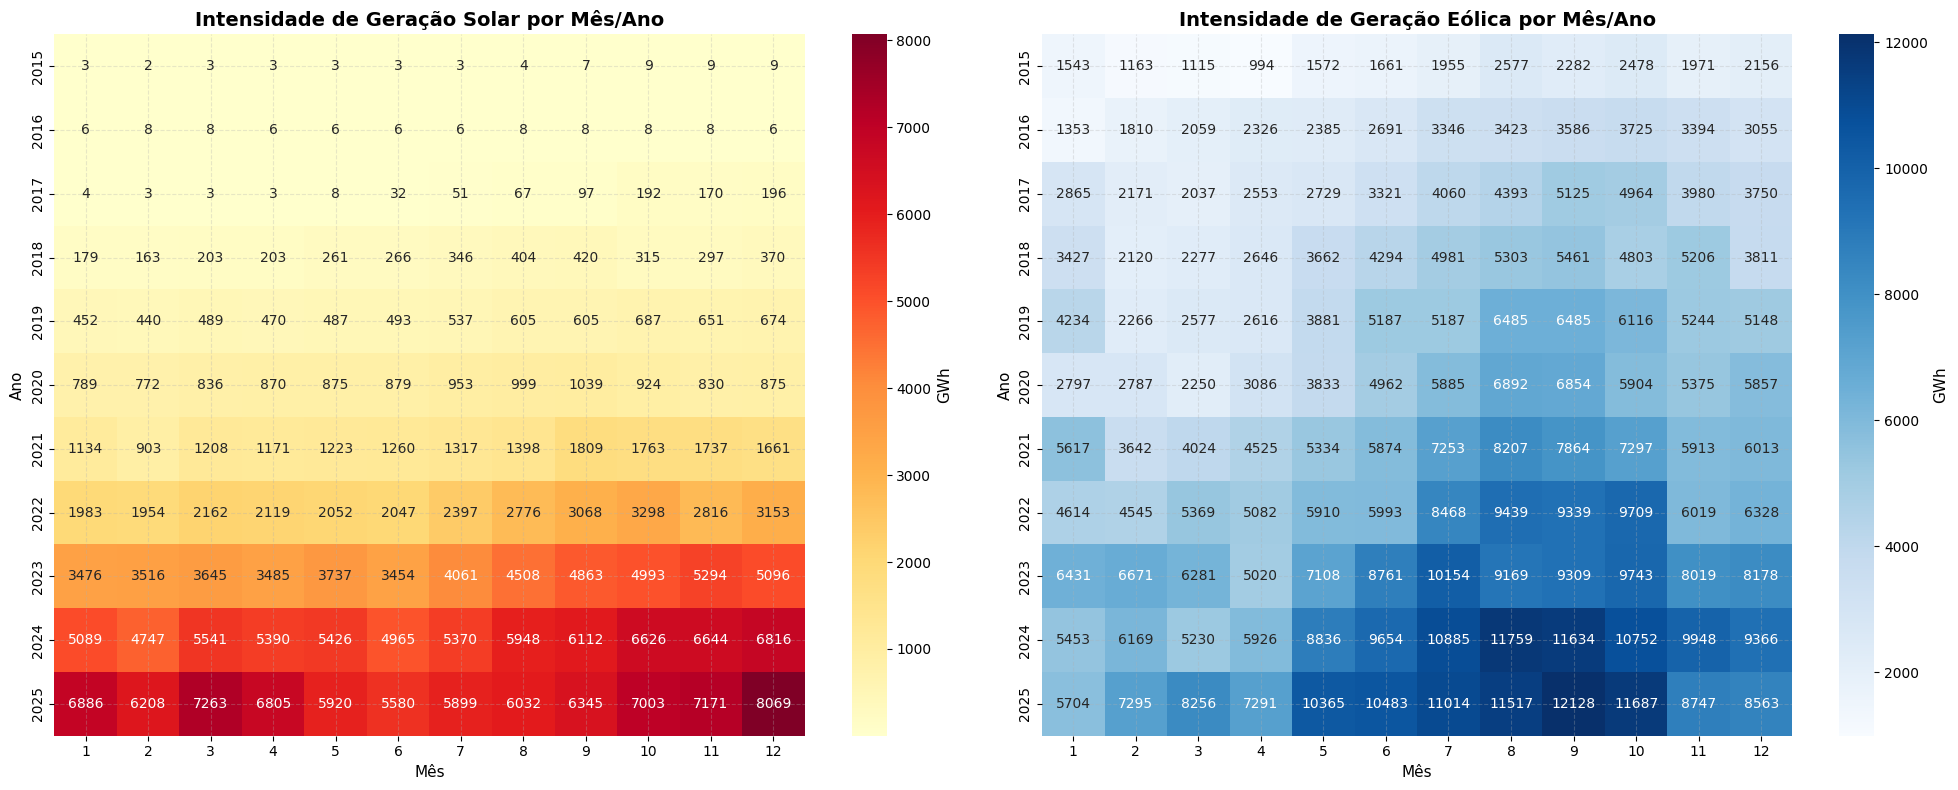

In [6]:
# ==============================================================================
# ETAPA 2.1: ANÁLISE EXPLORATÓRIA DE DADOS (EDA)
# Visão analítica do comportamento histórico (2015 - 2025)
# ==============================================================================

import matplotlib.ticker as mticker
import seaborn as sns

# --- Preparação de Dados para os Gráficos ---
# data_anual: Agrupamento anual por produto
data_anual = data_filt.groupby(['Ano', 'PRODUCT'])['VALUE'].sum().unstack(fill_value=0)

# data_br: Base para cálculo de share (usando a base bruta filtrada para o Brasil)
filtro_br = (df_raw["COUNTRY"].str.strip() == "Brazil") & (df_raw["Date"] >= "2015-01-01")
data_br = df_raw[filtro_br].copy()

# Gráfico 1 — Produção média mensal por fonte
media_mensal = data_filt.groupby("PRODUCT")["VALUE"].mean().sort_values()

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(media_mensal.index, media_mensal.values,
               color=[CORES.get(p,"#aaa") for p in media_mensal.index], edgecolor="white")

ax.bar_label(bars, labels=[f"{v:,.0f} GWh" for v in media_mensal.values], padding=5, fontsize=9)
ax.set_xlabel("Produção Média Mensal [GWh]")
ax.set_title("Brasil: Produção Média Mensal por Fonte (2015–2025)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
plt.tight_layout(); plt.show()

# Gráfico 2 — Pizza Renovável vs Não Renovável
rn_share = data_filt.groupby("Categoria")["share"].mean() * 100

fig, ax = plt.subplots(figsize=(7, 6))
wedges, texts, autotexts = ax.pie(
    rn_share, labels=rn_share.index, autopct="%.1f%%",
    startangle=90, counterclock=False, colors=["#d62728","#2ca02c"],
    explode=(0.04,0), wedgeprops={"edgecolor":"white","linewidth":2})
[at.set_fontsize(12) or at.set_fontweight("bold") for at in autotexts]
ax.set_title("Brasil: Participação Histórica Média\nRenovável vs Não Renovável (2015–2025)")
plt.tight_layout(); plt.show()

# Gráfico 3 — Evolução anual (área empilhada)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Brasil: Evolução Anual da Geração Elétrica por Fonte (GWh)")

# Subplot 1: Renováveis
fontes_r = [f for f in FONTES_RENOVAVEIS if f in data_anual.columns]
ax1.stackplot(data_anual.index, [data_anual[f] for f in fontes_r],
              labels=fontes_r,
              colors=[CORES[f] for f in fontes_r], alpha=0.85)
ax1.set_ylabel("GWh"); ax1.set_title("Fontes Renováveis", fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
ax1.legend(loc="upper left", ncol=3, fontsize=9)

# Subplot 2: Não Renováveis
fontes_nr = [f for f in FONTES_NAO_RENOVAVEIS if f in data_anual.columns]
ax2.stackplot(data_anual.index, [data_anual[f] for f in fontes_nr],
              labels=fontes_nr,
              colors=[CORES[f] for f in fontes_nr], alpha=0.85)
ax2.set_ylabel("GWh"); ax2.set_title("Fontes Não Renováveis", fontsize=11)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
ax2.legend(loc="upper left", ncol=3, fontsize=9)

ax2.set_xticks(data_anual.index)
ax2.set_xticklabels(data_anual.index, rotation=45, ha="right")
plt.tight_layout(); plt.show()

# Gráfico 4 - Solar e Eólica em destaque com CAGR
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(13, 6))

# Linhas de fundo (outras fontes) em cinza claro
for col in data_anual.columns:
    if col not in ["Solar","Wind"]:
        ax.plot(data_anual.index, data_anual[col], color="#EEEEEE", linewidth=1, alpha=0.5)

# Destaque para Solar e Eólica com cálculo de CAGR
for fonte, marker in [("Solar","o"),("Wind","s")]:
    if fonte in data_anual.columns:
        s = data_anual[fonte].dropna()
        n = len(s) - 1
        cagr_val = (s.iloc[-1]/s.iloc[0])**(1/n) - 1

        # legenda
        label_cagr = f"{fonte} (CAGR: {cagr_val:.1%})"

        ax.plot(data_anual.index, data_anual[fonte], color=CORES[fonte],
                linewidth=3, marker=marker, markersize=7, label=label_cagr)

ax.set_title("Brasil: Evolução da Geração Solar e Eólica")
ax.set_xlabel("Ano")
ax.set_ylabel("Produção Anual [GWh]")

# Ajustes de eixos e legenda
ax.set_xticks(data_anual.index)
ax.set_xticklabels(data_anual.index, rotation=45, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
ax.legend(title="Fontes e Crescimento (CAGR)", loc="upper left")

plt.tight_layout()
plt.show()

# Gráficos 5 e 6 — Share acumulado anual
df_dez  = data_br[data_br["MONTH_NAME"]=="December"].copy()
df_net  = (df_dez[df_dez["PRODUCT"]=="Net electricity production"]
           [["YEAR","yearToDate"]].rename(columns={"yearToDate":"total_anual_net"}))
df_sacc = pd.merge(df_dez, df_net, on="YEAR")
df_sacc["share_acumulado"] = df_sacc["yearToDate"] / df_sacc["total_anual_net"] * 100

for grupo, fontes, titulo_g in [
    ("Renováveis", FONTES_RENOVAVEIS, "Brasil: Share Acumulado Anual — Fontes Renováveis (%)"),
    ("Não Renováveis", FONTES_NAO_RENOVAVEIS, "Brasil: Share Acumulado Anual — Fontes Não Renováveis (%)"),
]:
    df_g = df_sacc[df_sacc["PRODUCT"].isin(fontes)]
    if df_g.empty: continue
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.barplot(data=df_g, x="YEAR", y="share_acumulado", hue="PRODUCT", palette=CORES, ax=ax, edgecolor="white")
    for cont in ax.containers:
        ax.bar_label(cont, fmt="%.1f%%", padding=3, fontsize=7, rotation=90)
    ax.set_ylim(0, df_g["share_acumulado"].max() + 15)
    ax.set_xlabel("Ano"); ax.set_ylabel("Participação Acumulada (%)")
    ax.set_title(titulo_g); ax.legend(title="Fonte", bbox_to_anchor=(1.01,1), loc="upper left")
    plt.xticks(rotation=45); plt.tight_layout();
    plt.show()

# Gráfico 7 - Heatmap Solar e eólica
# Preparação dos dados para o Heatmap
def preparar_heatmap(serie):
    df = serie.reset_index()
    df['Ano'] = df['Date'].dt.year
    df['Mes'] = df['Date'].dt.month
    return df.pivot(index="Ano", columns="Mes", values="VALUE")

# Criando os pivots
pivot_solar = preparar_heatmap(serie_solar)
pivot_wind = preparar_heatmap(serie_wind)

# Plotagem Lado a Lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Heatmap Solar
sns.heatmap(pivot_solar, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax1, cbar_kws={'label': 'GWh'})
ax1.set_title("Intensidade de Geração Solar por Mês/Ano", fontsize=14, fontweight='bold')
ax1.set_xlabel("Mês"); ax1.set_ylabel("Ano")

# Heatmap Eólica
sns.heatmap(pivot_wind, annot=True, fmt=".0f", cmap="Blues", ax=ax2, cbar_kws={'label': 'GWh'})
ax2.set_title("Intensidade de Geração Eólica por Mês/Ano", fontsize=14, fontweight='bold')
ax2.set_xlabel("Mês"); ax2.set_ylabel("Ano")

plt.tight_layout()
plt.show()

# ETAPA 3


ANÁLISE ESTATÍSTICA: ENERGIA SOLAR



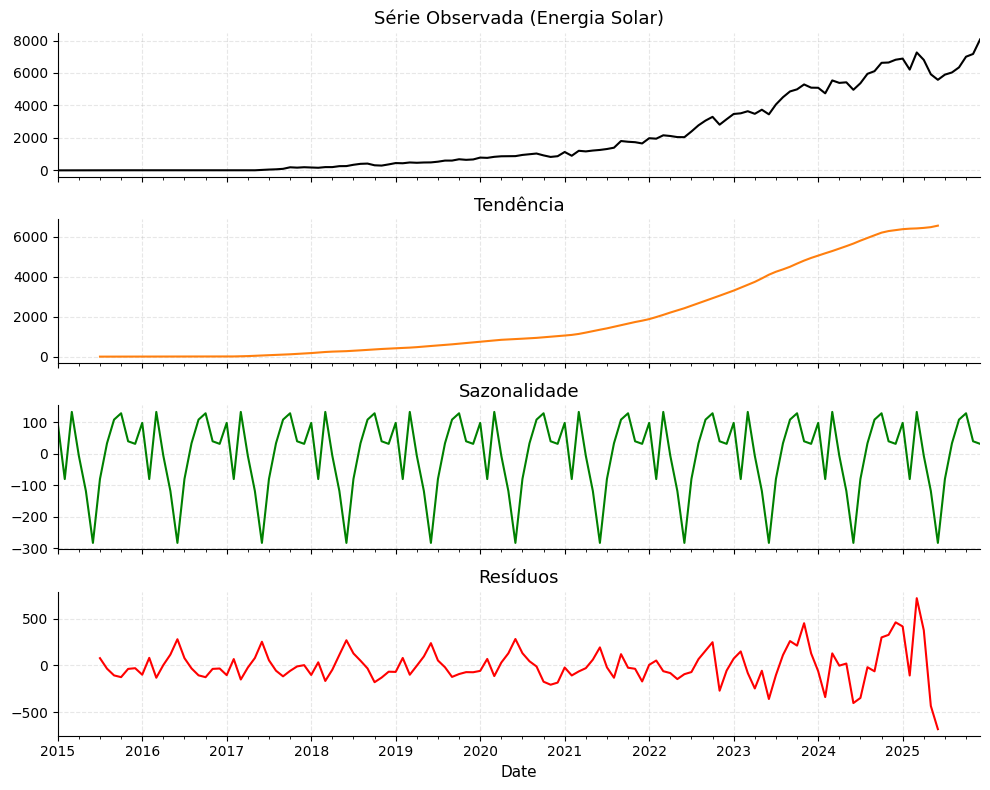

--- Teste Augmented Dickey-Fuller (ADF) - Energia Solar ---
Estatística do Teste: 0.7868
Valor-p: 0.9914
Conclusão: A série NÃO é estacionária (Requer diferenciação no SARIMA).


ANÁLISE ESTATÍSTICA: ENERGIA EÓLICA (WIND)



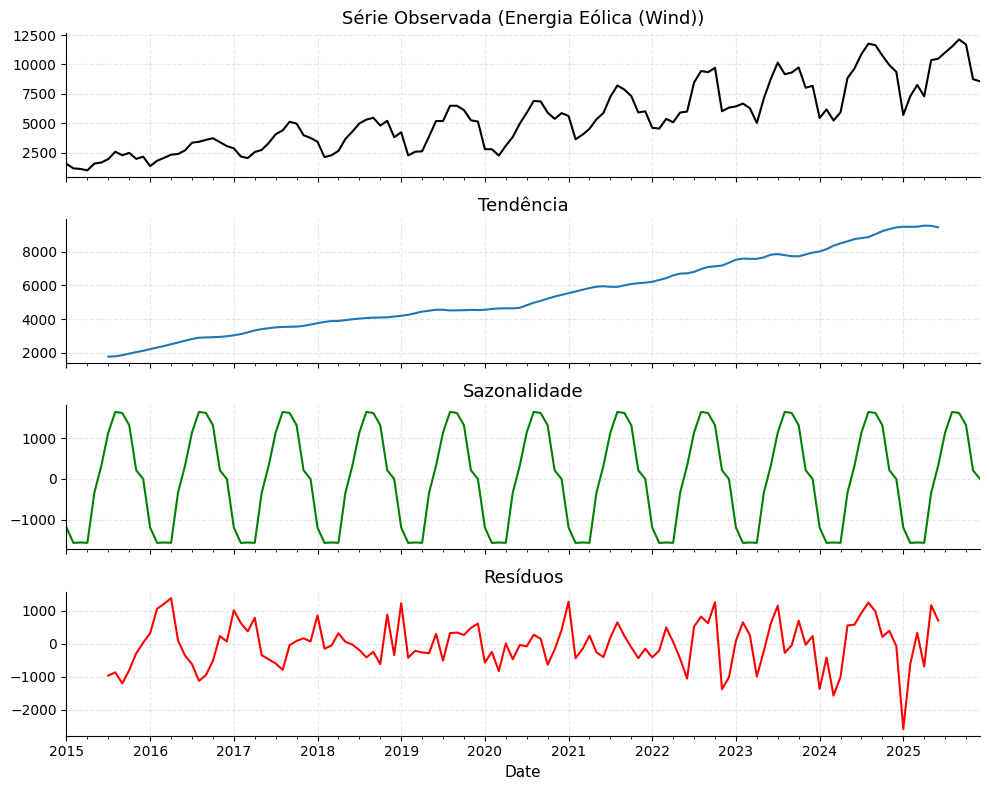

--- Teste Augmented Dickey-Fuller (ADF) - Energia Eólica (Wind) ---
Estatística do Teste: 0.3882
Valor-p: 0.9810
Conclusão: A série NÃO é estacionária (Requer diferenciação no SARIMA).



In [7]:
# ==============================================================================
# ETAPA 3: TRANSFORMAÇÃO E ANÁLISE ESTATÍSTICA
# Decomposição STL e Teste ADF para Energia Solar e Eólica
# ==============================================================================

def realizar_analise_estatistica(serie, nome_fonte, cor_tendencia):
    """
    Função para gerar a decomposição STL e aplicar o Teste ADF numa série temporal.
    """
    print(f"\n{'='*60}")
    print(f"ANÁLISE ESTATÍSTICA: {nome_fonte.upper()}")
    print(f"{'='*60}\n")

    # 1. Decomposição STL
    decomposicao = seasonal_decompose(serie, model='additive', period=12)

    # Plotagem dos subgráficos da decomposição
    fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
    decomposicao.observed.plot(ax=axes[0], color='black', title=f'Série Observada ({nome_fonte})')
    decomposicao.trend.plot(ax=axes[1], color=cor_tendencia, title='Tendência')
    decomposicao.seasonal.plot(ax=axes[2], color='green', title='Sazonalidade')
    decomposicao.resid.plot(ax=axes[3], color='red', title='Resíduos')
    plt.tight_layout()
    plt.show()

    # 2. Teste ADF de Estacionariedade
    resultado_adf = adfuller(serie)
    print(f"--- Teste Augmented Dickey-Fuller (ADF) - {nome_fonte} ---")
    print(f"Estatística do Teste: {resultado_adf[0]:.4f}")
    print(f"Valor-p: {resultado_adf[1]:.4f}")

    if resultado_adf[1] <= 0.05:
        print("Conclusão: A série é estacionária (Rejeita-se a hipótese nula).\n")
    else:
        print("Conclusão: A série NÃO é estacionária (Requer diferenciação no SARIMA).\n")

# --- EXECUÇÃO DAS ANÁLISES ---
# Análise para a Energia Solar
realizar_analise_estatistica(serie_solar, "Energia Solar", cor_tendencia="#ff7f0e")

# Análise para a Energia Eólica
realizar_analise_estatistica(serie_wind, "Energia Eólica (Wind)", cor_tendencia="#1f77b4")

# ETAPA 4

In [8]:
# ==============================================================================
# ETAPA 4: MINERAÇÃO DE DADOS (DATA MINING)
# Modelagem SARIMA e Prophet para Solar e eólica
# ==============================================================================

PERIODOS_FUTURO = 12 # Projeção de 1 ano à frente

def aplicar_modelos(serie):
    # --- MODELO SARIMA ---
    modelo_sarima = sm.tsa.statespace.SARIMAX(serie, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12),
                                              enforce_stationarity=False, enforce_invertibility=False)
    fit_sarima = modelo_sarima.fit(disp=False)

    # Extração de dados SARIMA
    prev_sarima_futuro = fit_sarima.get_forecast(steps=PERIODOS_FUTURO).predicted_mean
    prev_sarima_hist = fit_sarima.fittedvalues

    # --- MODELO PROPHET ---
    df_prophet = pd.DataFrame({'ds': serie.index, 'y': serie.values})
    modelo_prophet = Prophet()
    modelo_prophet.fit(df_prophet)

    # Extração de dados Prophet
    df_futuro = modelo_prophet.make_future_dataframe(periods=PERIODOS_FUTURO, freq='MS')
    prev_prophet_completa = modelo_prophet.predict(df_futuro)

    prev_prophet_futuro = prev_prophet_completa.tail(PERIODOS_FUTURO)
    prev_prophet_hist = prev_prophet_completa['yhat'][:-PERIODOS_FUTURO].values

    return prev_sarima_futuro, prev_sarima_hist, prev_prophet_futuro, prev_prophet_hist

print("Treinando modelos para Energia Solar...")
s_futuro_solar, s_hist_solar, p_futuro_solar, p_hist_solar = aplicar_modelos(serie_solar)

print("Treinando modelos para Energia Eólica...")
s_futuro_wind, s_hist_wind, p_futuro_wind, p_hist_wind = aplicar_modelos(serie_wind)

print("Treinamento e predições concluídos com sucesso!")

Treinando modelos para Energia Solar...


17:04:36 - cmdstanpy - INFO - Chain [1] start processing
17:04:37 - cmdstanpy - INFO - Chain [1] done processing


Treinando modelos para Energia Eólica...


17:04:38 - cmdstanpy - INFO - Chain [1] start processing
17:04:38 - cmdstanpy - INFO - Chain [1] done processing


Treinamento e predições concluídos com sucesso!


# ETAPA 5

--- AVALIAÇÃO DE DESEMPENHO: ENERGIA SOLAR ---
SARIMA  -> MAE: 111.26 | RMSE: 198.31 | MAPE: 14.24%
PROPHET -> MAE: 196.88 | RMSE: 277.78 | MAPE: 763.40%
-------------------------------------------------------
--- AVALIAÇÃO DE DESEMPENHO: ENERGIA EÓLICA (WIND) ---
SARIMA  -> MAE: 558.27 | RMSE: 722.26 | MAPE: 13.92%
PROPHET -> MAE: 587.17 | RMSE: 721.64 | MAPE: 15.00%
-------------------------------------------------------


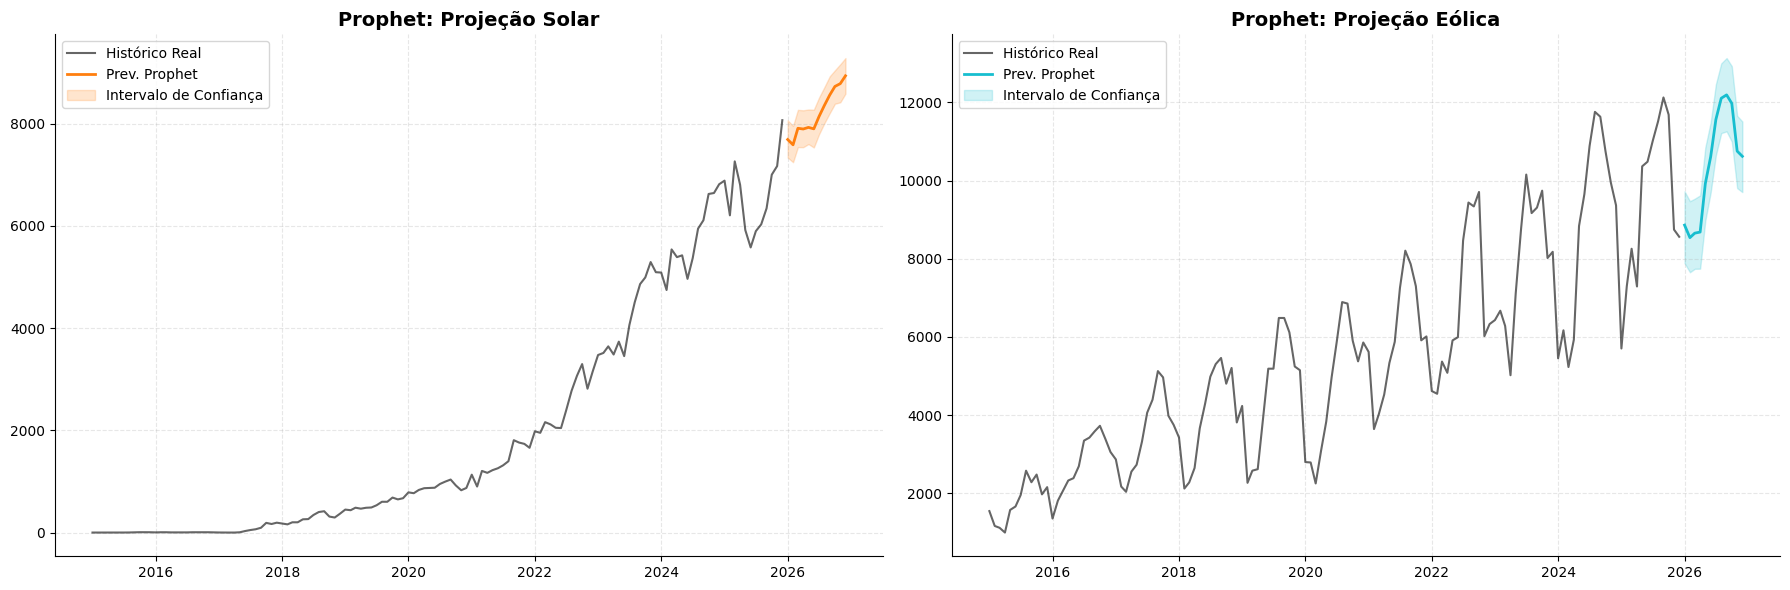


              TABELA DE PREVISÕES PARA 2026 (GWh)
    Mês  Solar - SARIMA  Solar - Prophet  Wind - SARIMA  Wind - Prophet
2026-01          7980.9           7691.1         6767.0          8861.2
2026-02          7373.2           7587.5         7975.1          8540.3
2026-03          8353.7           7910.6         8317.2          8655.6
2026-04          7951.5           7896.8         7911.1          8683.1
2026-05          7236.6           7928.1        10557.3          9924.7
2026-06          6886.2           7900.0        11092.8         10613.3
2026-07          7225.4           8140.1        12065.3         11563.2
2026-08          7430.6           8357.6        12531.0         12107.7
2026-09          7725.3           8561.6        12802.1         12193.7
2026-10          8341.0           8729.2        12398.3         11976.0
2026-11          8487.7           8784.2        10236.3         10755.2
2026-12          9244.8           8937.3        10038.1         10621.4



In [9]:
# ==============================================================================
# ETAPA 5: INTERPRETAÇÃO E AVALIAÇÃO
# Métricas, Tabela de Previsões para 2026 e Gráficos Comparativos
# ==============================================================================

# 1. Função auxiliar para cálculo do MAPE
def calcular_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def imprimir_metricas(nome, serie, s_hist, p_hist):
    print(f"--- AVALIAÇÃO DE DESEMPENHO: {nome} ---")
    print(f"SARIMA  -> MAE: {mean_absolute_error(serie, s_hist):.2f} | RMSE: {np.sqrt(mean_squared_error(serie, s_hist)):.2f} | MAPE: {calcular_mape(serie, s_hist):.2f}%")
    print(f"PROPHET -> MAE: {mean_absolute_error(serie, p_hist):.2f} | RMSE: {np.sqrt(mean_squared_error(serie, p_hist)):.2f} | MAPE: {calcular_mape(serie, p_hist):.2f}%")
    print("-" * 55)

# Cálculo de Métricas
imprimir_metricas("ENERGIA SOLAR", serie_solar, s_hist_solar, p_hist_solar)
imprimir_metricas("ENERGIA EÓLICA (WIND)", serie_wind, s_hist_wind, p_hist_wind)

# 2. Gráficos Prophet Lado a Lado
fig, (ax_p1, ax_p2) = plt.subplots(1, 2, figsize=(18, 6))

# Solar - Prophet
ax_p1.plot(serie_solar.index, serie_solar.values, label='Histórico Real', color='black', alpha=0.6)
ax_p1.plot(p_futuro_solar['ds'], p_futuro_solar['yhat'], label='Prev. Prophet', color='#ff7f0e', linewidth=2)
ax_p1.fill_between(p_futuro_solar['ds'], p_futuro_solar['yhat_lower'], p_futuro_solar['yhat_upper'], color='#ff7f0e', alpha=0.2, label='Intervalo de Confiança')
ax_p1.set_title("Prophet: Projeção Solar", fontsize=14, fontweight='bold')
ax_p1.legend()

# Eólica - Prophet
ax_p2.plot(serie_wind.index, serie_wind.values, label='Histórico Real', color='black', alpha=0.6)
ax_p2.plot(p_futuro_wind['ds'], p_futuro_wind['yhat'], label='Prev. Prophet', color='#17becf', linewidth=2)
ax_p2.fill_between(p_futuro_wind['ds'], p_futuro_wind['yhat_lower'], p_futuro_wind['yhat_upper'], color='#17becf', alpha=0.2, label='Intervalo de Confiança')
ax_p2.set_title("Prophet: Projeção Eólica", fontsize=14, fontweight='bold')
ax_p2.legend()

plt.tight_layout()
plt.show()

# 3. Tabela de Previsões para 2026
meses_2026 = s_futuro_solar.index.strftime('%Y-%m')
df_previsoes_2026 = pd.DataFrame({
    'Mês': meses_2026,
    'Solar - SARIMA': s_futuro_solar.values.round(1),
    'Solar - Prophet': p_futuro_solar['yhat'].values.round(1),
    'Wind - SARIMA': s_futuro_wind.values.round(1),
    'Wind - Prophet': p_futuro_wind['yhat'].values.round(1)
})

print("\n" + "="*75)
print("              TABELA DE PREVISÕES PARA 2026 (GWh)")
print("="*75)
print(df_previsoes_2026.to_string(index=False))
print("="*75 + "\n")

## Gráfico projeção solar e eólica — Modelo SARIMA (Lado a Lado) 2026


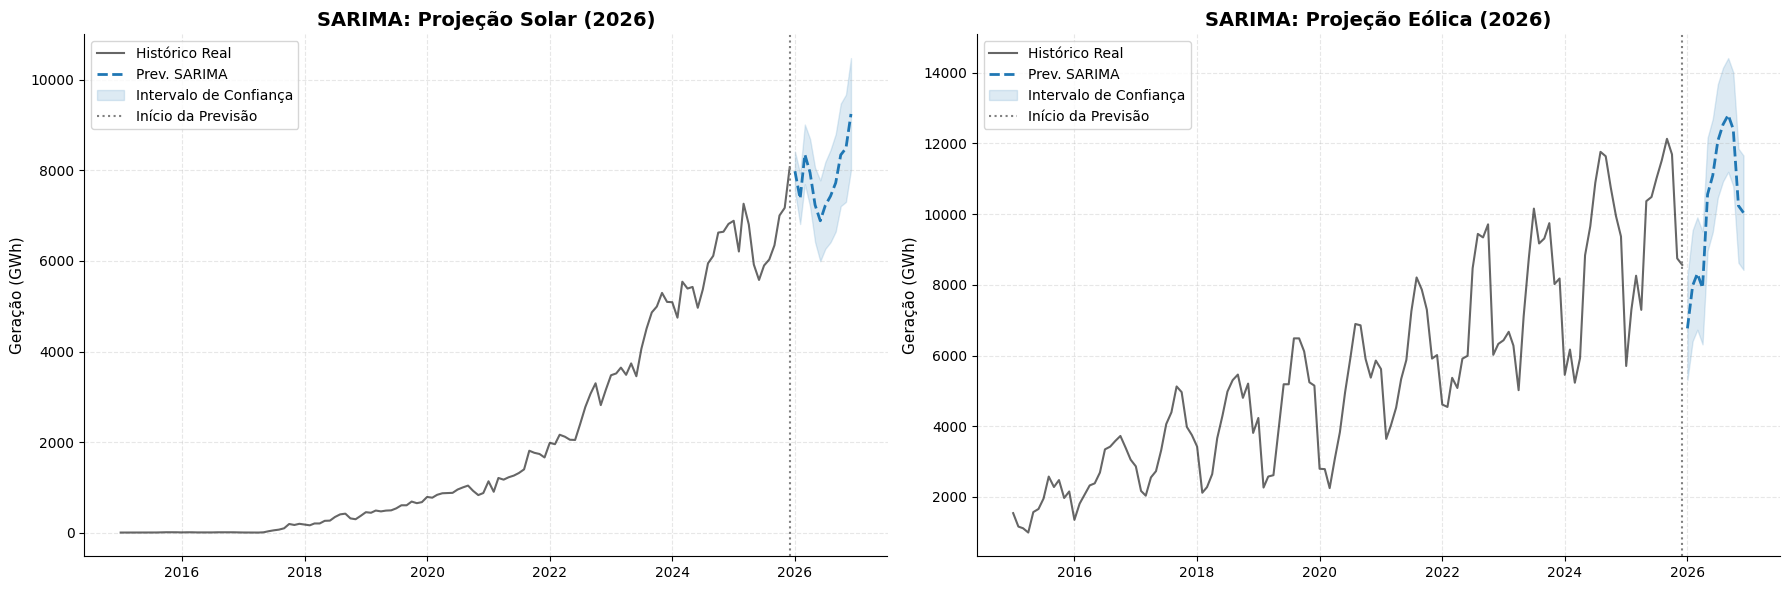

In [10]:
import matplotlib.pyplot as plt

# Criando a figura para comparação SARIMA lado a lado
fig, (ax_s1, ax_s2) = plt.subplots(1, 2, figsize=(18, 6))

# --- Solar - SARIMA ---
# Realizando o forecast novamente para obter o intervalo de confiança
modelo_s = sm.tsa.statespace.SARIMAX(serie_solar, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12), enforce_stationarity=False, enforce_invertibility=False)
res_s = modelo_s.fit(disp=False)
pred_s = res_s.get_forecast(steps=PERIODOS_FUTURO)
pred_conf_s = pred_s.conf_int()

ax_s1.plot(serie_solar.index, serie_solar.values, label='Histórico Real', color='black', alpha=0.6)
ax_s1.plot(s_futuro_solar.index, s_futuro_solar.values, label='Prev. SARIMA', color='#1f77b4', linewidth=2, linestyle='--')
ax_s1.fill_between(pred_conf_s.index, pred_conf_s.iloc[:, 0], pred_conf_s.iloc[:, 1], color='#1f77b4', alpha=0.15, label='Intervalo de Confiança')
ax_s1.axvline(x=serie_solar.index[-1], color='gray', linestyle=':', label='Início da Previsão')
ax_s1.set_title("SARIMA: Projeção Solar (2026)", fontsize=14, fontweight='bold')
ax_s1.set_ylabel("Geração (GWh)")
ax_s1.legend()

# --- Eólica - SARIMA ---
modelo_w = sm.tsa.statespace.SARIMAX(serie_wind, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12), enforce_stationarity=False, enforce_invertibility=False)
res_w = modelo_w.fit(disp=False)
pred_w = res_w.get_forecast(steps=PERIODOS_FUTURO)
pred_conf_w = pred_w.conf_int()

ax_s2.plot(serie_wind.index, serie_wind.values, label='Histórico Real', color='black', alpha=0.6)
ax_s2.plot(s_futuro_wind.index, s_futuro_wind.values, label='Prev. SARIMA', color='#1f77b4', linewidth=2, linestyle='--')
ax_s2.fill_between(pred_conf_w.index, pred_conf_w.iloc[:, 0], pred_conf_w.iloc[:, 1], color='#1f77b4', alpha=0.15, label='Intervalo de Confiança')
ax_s2.axvline(x=serie_wind.index[-1], color='gray', linestyle=':', label='Início da Previsão')
ax_s2.set_title("SARIMA: Projeção Eólica (2026)", fontsize=14, fontweight='bold')
ax_s2.set_ylabel("Geração (GWh)")
ax_s2.legend()

plt.tight_layout()
plt.show()

## Gráfico de barras - Avaliação das Métricas (MAE, RMSE, MAPE) — Modelo Prophet


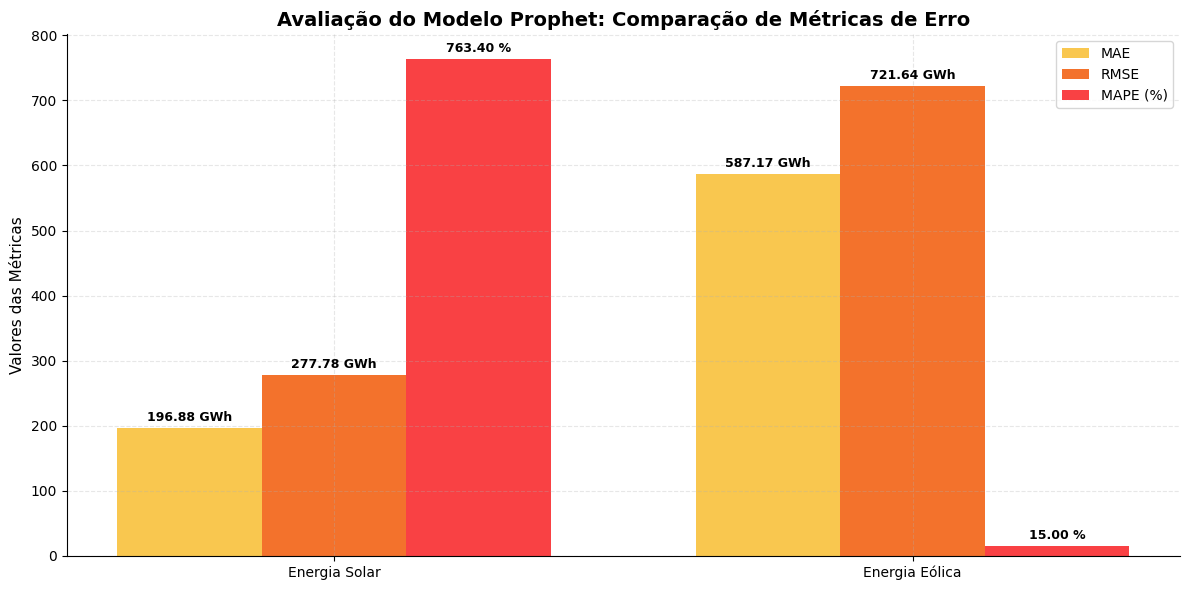

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Preparação dos dados de métricas para o Prophet
labels = ['Energia Solar', 'Energia Eólica']
mae_vals = [mean_absolute_error(serie_solar, p_hist_solar), mean_absolute_error(serie_wind, p_hist_wind)]
rmse_vals = [np.sqrt(mean_squared_error(serie_solar, p_hist_solar)), np.sqrt(mean_squared_error(serie_wind, p_hist_wind))]
mape_vals = [calcular_mape(serie_solar, p_hist_solar), calcular_mape(serie_wind, p_hist_wind)]

x = np.arange(len(labels))  # Localização das etiquetas
width = 0.25  # Largura das barras

fig, ax = plt.subplots(figsize=(12, 6))

# Criando as barras para cada métrica
rects1 = ax.bar(x - width, mae_vals, width, label='MAE', color='#f9c74f')
rects2 = ax.bar(x, rmse_vals, width, label='RMSE', color='#f3722c')
rects3 = ax.bar(x + width, mape_vals, width, label='MAPE (%)', color='#f94144')

# Textos, títulos e legendas
ax.set_ylabel('Valores das Métricas')
ax.set_title('Avaliação do Modelo Prophet: Comparação de Métricas de Erro', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Função para adicionar rótulos sobre as barras com unidades
def autolabel(rects, unit=""):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f} {unit}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1, "GWh")
autolabel(rects2, "GWh")
autolabel(rects3, "%")

plt.tight_layout()
plt.show()

## Gráfico de barras - Avaliação das Métricas (MAE, RMSE, MAPE) — Modelo SARIMA

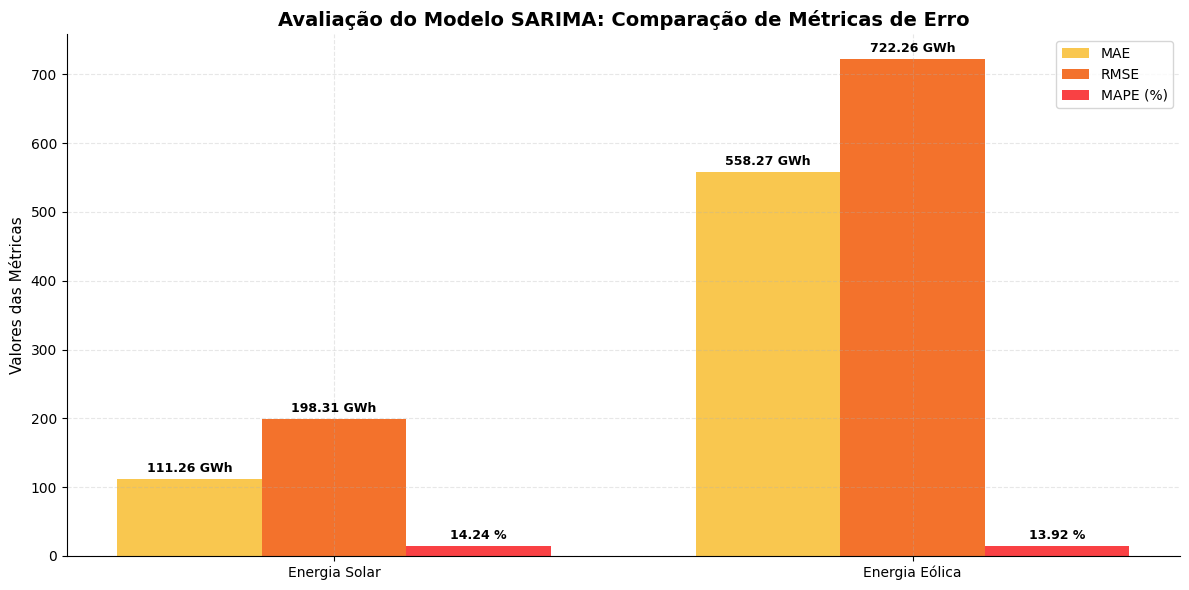

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Preparação dos dados de métricas para o SARIMA
labels_s = ['Energia Solar', 'Energia Eólica']
mae_s = [mean_absolute_error(serie_solar, s_hist_solar), mean_absolute_error(serie_wind, s_hist_wind)]
rmse_s = [np.sqrt(mean_squared_error(serie_solar, s_hist_solar)), np.sqrt(mean_squared_error(serie_wind, s_hist_wind))]
mape_s = [calcular_mape(serie_solar, s_hist_solar), calcular_mape(serie_wind, s_hist_wind)]

x_s = np.arange(len(labels_s))  # Localização das etiquetas
width_s = 0.25  # Largura das barras

fig, ax = plt.subplots(figsize=(12, 6))

# Criando as barras para cada métrica
rects1s = ax.bar(x_s - width_s, mae_s, width_s, label='MAE', color='#f9c74f')
rects2s = ax.bar(x_s, rmse_s, width_s, label='RMSE', color='#f3722c')
rects3s = ax.bar(x_s + width_s, mape_s, width_s, label='MAPE (%)', color='#f94144')

# Textos, títulos e legendas
ax.set_ylabel('Valores das Métricas')
ax.set_title('Avaliação do Modelo SARIMA: Comparação de Métricas de Erro', fontsize=14, fontweight='bold')
ax.set_xticks(x_s)
ax.set_xticklabels(labels_s)
ax.legend()

# Reutilizando a lógica de rótulos
def autolabel_sarima(rects, unit=""):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f} {unit}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel_sarima(rects1s, "GWh")
autolabel_sarima(rects2s, "GWh")
autolabel_sarima(rects3s, "%")

plt.tight_layout()
plt.show()

## Gráfico de barrras - Comparativo de Desempenho (MAE, RMSE e MAPE): SARIMA vs Prophet


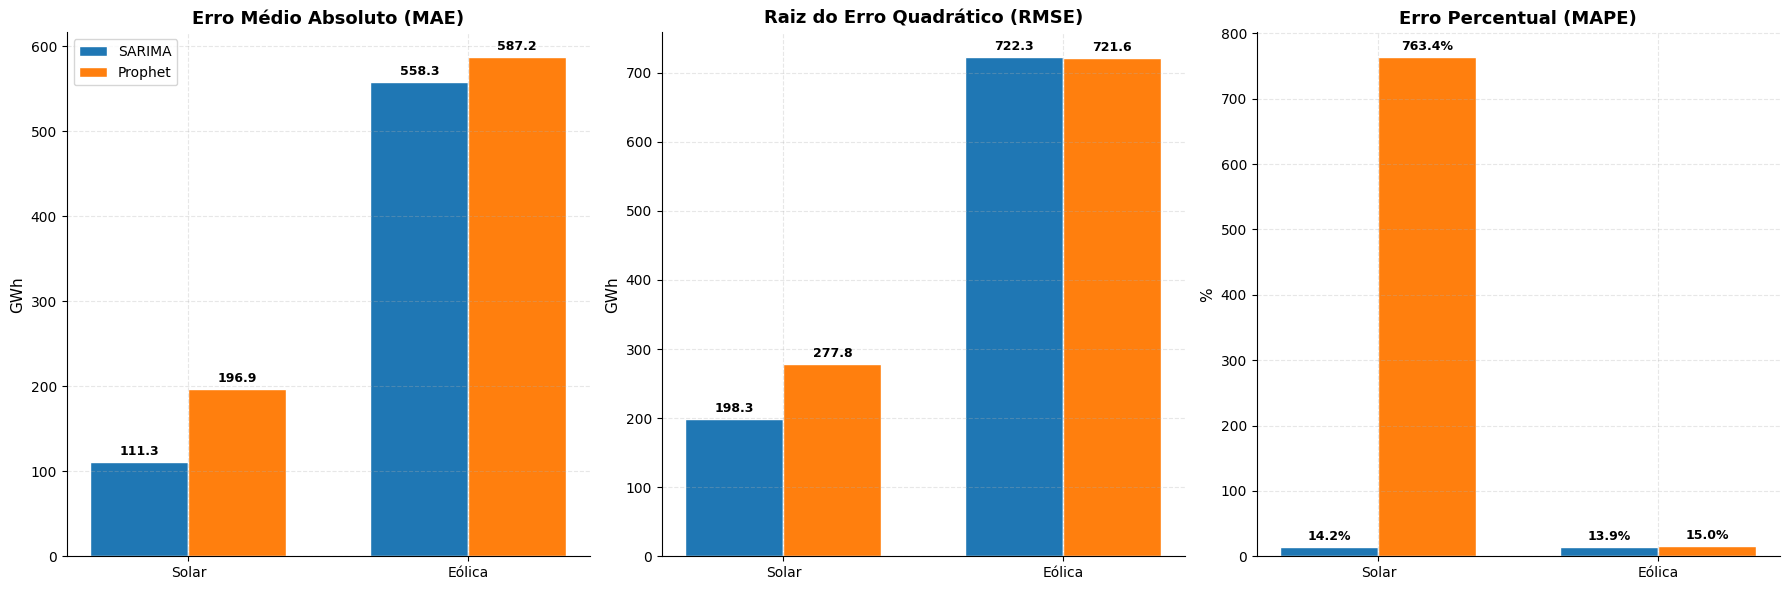

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Preparação dos dados: Comparativo SARIMA vs Prophet (MAE, RMSE, MAPE)
labels = ['Solar', 'Eólica']

# Métricas SARIMA
mae_sarima = [mean_absolute_error(serie_solar, s_hist_solar), mean_absolute_error(serie_wind, s_hist_wind)]
rmse_sarima = [np.sqrt(mean_squared_error(serie_solar, s_hist_solar)), np.sqrt(mean_squared_error(serie_wind, s_hist_wind))]
mape_sarima = [calcular_mape(serie_solar, s_hist_solar), calcular_mape(serie_wind, s_hist_wind)]

# Métricas Prophet
mae_prophet = [mean_absolute_error(serie_solar, p_hist_solar), mean_absolute_error(serie_wind, p_hist_wind)]
rmse_prophet = [np.sqrt(mean_squared_error(serie_solar, p_hist_solar)), np.sqrt(mean_squared_error(serie_wind, p_hist_wind))]
mape_prophet = [calcular_mape(serie_solar, p_hist_solar), calcular_mape(serie_wind, p_hist_wind)]

# Configuração do Layout de Subplots (um para cada métrica)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
x = np.arange(len(labels))
width = 0.35

# 1. Gráfico MAE
rects1_mae = ax1.bar(x - width/2, mae_sarima, width, label='SARIMA', color='#1f77b4', edgecolor='white')
rects2_mae = ax1.bar(x + width/2, mae_prophet, width, label='Prophet', color='#ff7f0e', edgecolor='white')
ax1.set_title('Erro Médio Absoluto (MAE)', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylabel('GWh')
ax1.legend()

# 2. Gráfico RMSE
rects1_rmse = ax2.bar(x - width/2, rmse_sarima, width, label='SARIMA', color='#1f77b4', edgecolor='white')
rects2_rmse = ax2.bar(x + width/2, rmse_prophet, width, label='Prophet', color='#ff7f0e', edgecolor='white')
ax2.set_title('Raiz do Erro Quadrático (RMSE)', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_ylabel('GWh')

# 3. Gráfico MAPE
rects1_mape = ax3.bar(x - width/2, mape_sarima, width, label='SARIMA', color='#1f77b4', edgecolor='white')
rects2_mape = ax3.bar(x + width/2, mape_prophet, width, label='Prophet', color='#ff7f0e', edgecolor='white')
ax3.set_title('Erro Percentual (MAPE)', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(labels)
ax3.set_ylabel('%')

# Função de rótulos adaptada para os 3 subplots
def autolabel(rects, ax, unit=""):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}{unit}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1_mae, ax1)
autolabel(rects2_mae, ax1)
autolabel(rects1_rmse, ax2)
autolabel(rects2_rmse, ax2)
autolabel(rects1_mape, ax3, "%")
autolabel(rects2_mape, ax3, "%")

plt.tight_layout()
plt.show()


## Gráfico das Projeções Individuais de Crescimento Solar e eólica (2026)

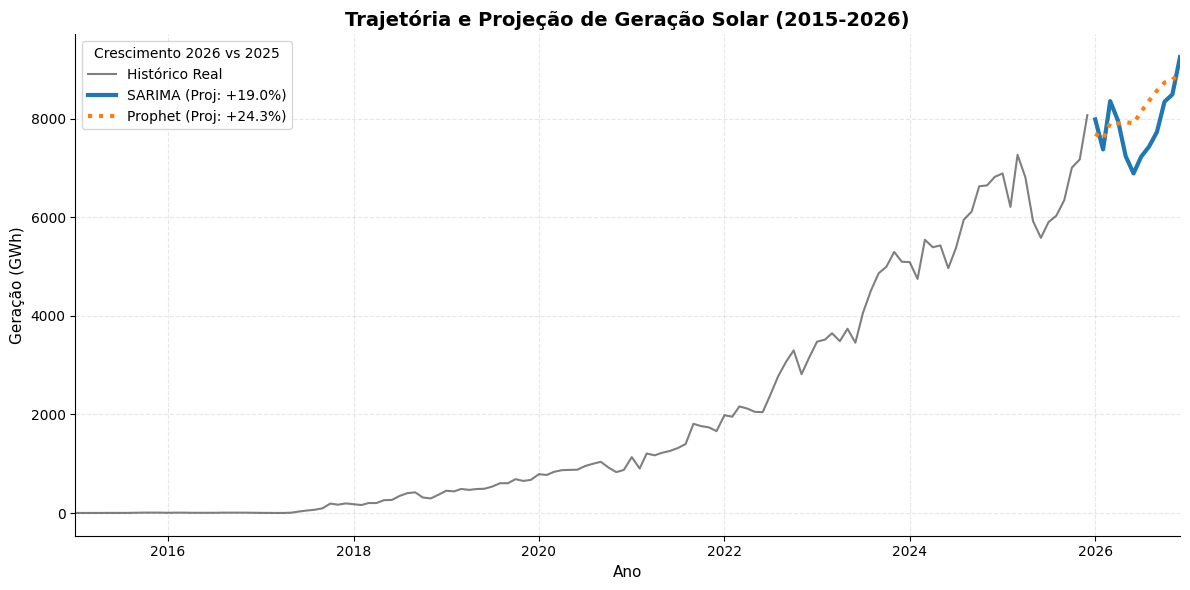

In [14]:
import matplotlib.dates as mdates

def calc_crescimento(serie_historica, serie_previsao):
    """
    Calcula o crescimento percentual da média do último ano histórico
    para a média do ano de previsão.
    """
    ultimo_ano_historico = serie_historica.index.year.max()
    media_historica = serie_historica[serie_historica.index.year == ultimo_ano_historico].mean()

    # Se for um dataframe do Prophet, extrai a coluna ds e yhat
    if isinstance(serie_previsao, pd.DataFrame) and 'ds' in serie_previsao.columns:
        serie_previsao = pd.Series(serie_previsao['yhat'].values, index=pd.to_datetime(serie_previsao['ds']))

    # Se for uma série sem DatetimeIndex
    if not isinstance(serie_previsao.index, pd.DatetimeIndex):
        proximo_ano = ultimo_ano_historico + 1
        idx = pd.date_range(start=f'{proximo_ano}-01-01', periods=len(serie_previsao), freq='MS')
        serie_previsao = pd.Series(serie_previsao.values, index=idx)

    ano_previsao = serie_previsao.index.year.min()
    media_previsao = serie_previsao[serie_previsao.index.year == ano_previsao].mean()

    if media_historica == 0:
        return 0
    return ((media_previsao - media_historica) / media_historica) * 100


# Gráfico Individual: Projeção Solar 2026
fig, ax = plt.subplots(figsize=(12, 6))

c_solar_s = calc_crescimento(serie_solar, s_futuro_solar)
c_solar_p = calc_crescimento(serie_solar, p_futuro_solar)

ax.plot(serie_solar.index, serie_solar.values, label='Histórico Real', color='black', alpha=0.5, linewidth=1.5)
ax.plot(s_futuro_solar.index, s_futuro_solar.values, label=f'SARIMA (Proj: +{c_solar_s:.1f}%)', color='#1f77b4', linewidth=3)
ax.plot(pd.to_datetime(p_futuro_solar['ds']), p_futuro_solar['yhat'], label=f'Prophet (Proj: +{c_solar_p:.1f}%)', color='#ff7f0e', linewidth=3, linestyle=':')

ax.set_title("Trajetória e Projeção de Geração Solar (2015-2026)", fontsize=14, fontweight='bold')
ax.set_ylabel("Geração (GWh)")
ax.set_xlabel("Ano")
ax.legend(title="Crescimento 2026 vs 2025", loc='upper left')
ax.set_xlim([pd.Timestamp('2015-01-01'), pd.Timestamp('2026-12-01')])
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

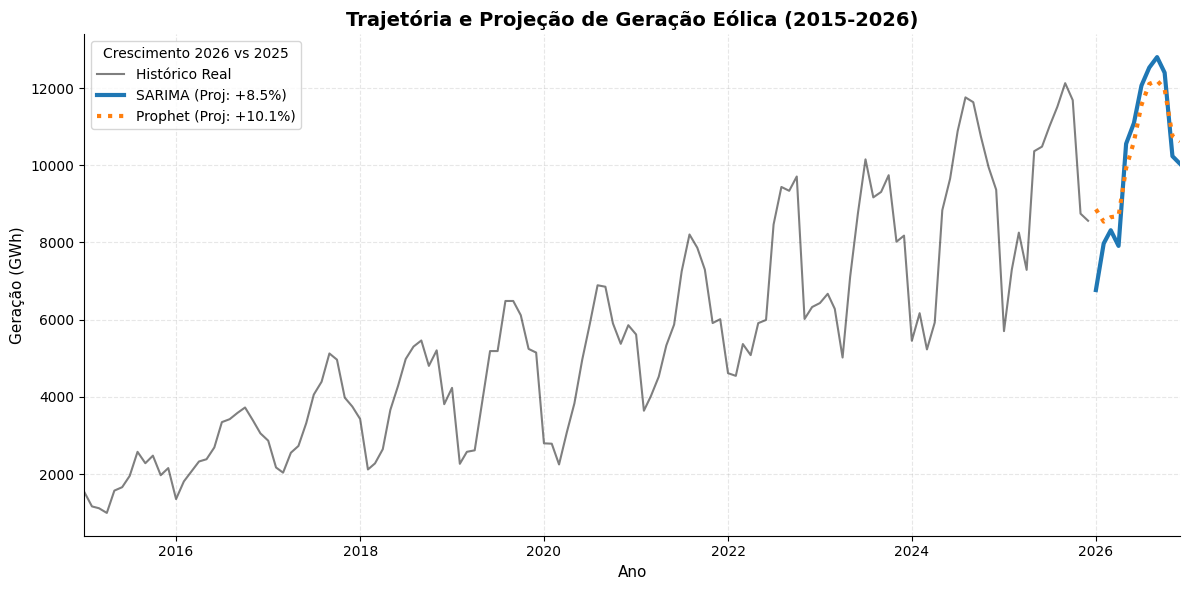

In [15]:
import matplotlib.dates as mdates

# Gráfico Individual: Projeção Eólica 2026
fig, ax = plt.subplots(figsize=(12, 6))

c_wind_s = calc_crescimento(serie_wind, s_futuro_wind)
c_wind_p = calc_crescimento(serie_wind, p_futuro_wind['yhat'])

ax.plot(serie_wind.index, serie_wind.values, label='Histórico Real', color='black', alpha=0.5, linewidth=1.5)
ax.plot(s_futuro_wind.index, s_futuro_wind.values, label=f'SARIMA (Proj: +{c_wind_s:.1f}%)', color='#1f77b4', linewidth=3)
ax.plot(p_futuro_wind['ds'], p_futuro_wind['yhat'], label=f'Prophet (Proj: +{c_wind_p:.1f}%)', color='#ff7f0e', linewidth=3, linestyle=':')

ax.set_title("Trajetória e Projeção de Geração Eólica (2015-2026)", fontsize=14, fontweight='bold')
ax.set_ylabel("Geração (GWh)")
ax.set_xlabel("Ano")
ax.legend(title="Crescimento 2026 vs 2025", loc='upper left')
ax.set_xlim([pd.Timestamp('2015-01-01'), pd.Timestamp('2026-12-01')])
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

## Gráficos lado a lado: SARIMA e Prophet para Solar e Eólica

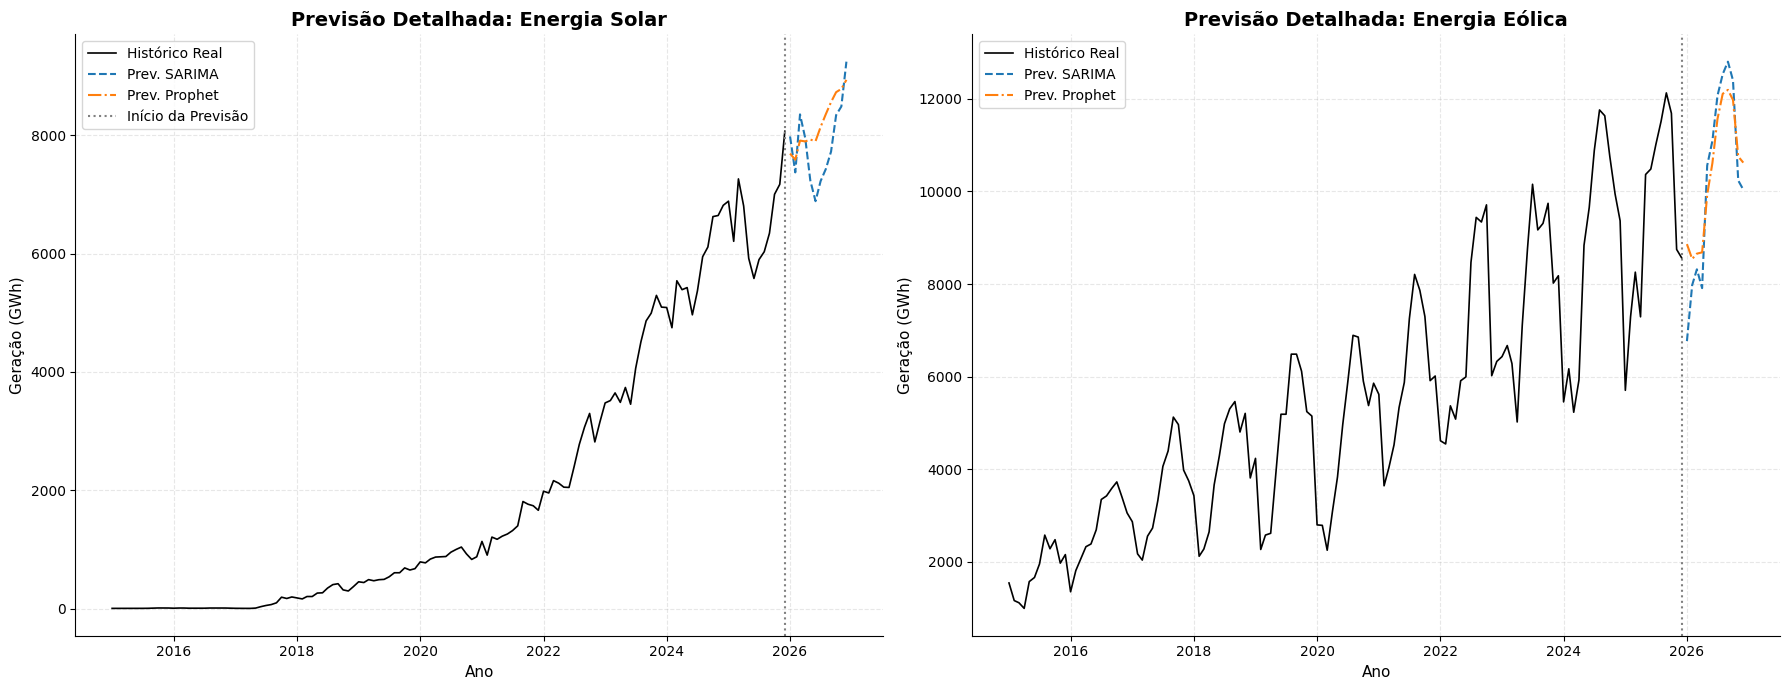

In [16]:
import matplotlib.pyplot as plt

# Cria a figura com 1 linha e 2 colunas para comparação lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- Gráfico 1: Energia Solar ---
ax1.plot(serie_solar.index, serie_solar.values, label='Histórico Real', color='black', linewidth=1.2)
ax1.plot(s_futuro_solar.index, s_futuro_solar.values, label='Prev. SARIMA', color='#1f77b4', linestyle='--')
ax1.plot(p_futuro_solar['ds'], p_futuro_solar['yhat'], label='Prev. Prophet', color='#ff7f0e', linestyle='-.')
ax1.axvline(x=serie_solar.index[-1], color='gray', linestyle=':', linewidth=1.5, label='Início da Previsão')
ax1.set_title('Previsão Detalhada: Energia Solar', fontsize=14, fontweight='bold')
ax1.set_ylabel('Geração (GWh)')
ax1.set_xlabel('Ano')
ax1.legend(loc='upper left', fontsize=10)

# --- Gráfico 2: Energia Eólica ---
ax2.plot(serie_wind.index, serie_wind.values, label='Histórico Real', color='black', linewidth=1.2)
ax2.plot(s_futuro_wind.index, s_futuro_wind.values, label='Prev. SARIMA', color='#1f77b4', linestyle='--')
ax2.plot(p_futuro_wind['ds'], p_futuro_wind['yhat'], label='Prev. Prophet', color='#ff7f0e', linestyle='-.')
ax2.axvline(x=serie_wind.index[-1], color='gray', linestyle=':', linewidth=1.5)
ax2.set_title('Previsão Detalhada: Energia Eólica', fontsize=14, fontweight='bold')
ax2.set_ylabel('Geração (GWh)')
ax2.set_xlabel('Ano')
ax2.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

## Gráficos modelo Prophet: Solar e Eólica

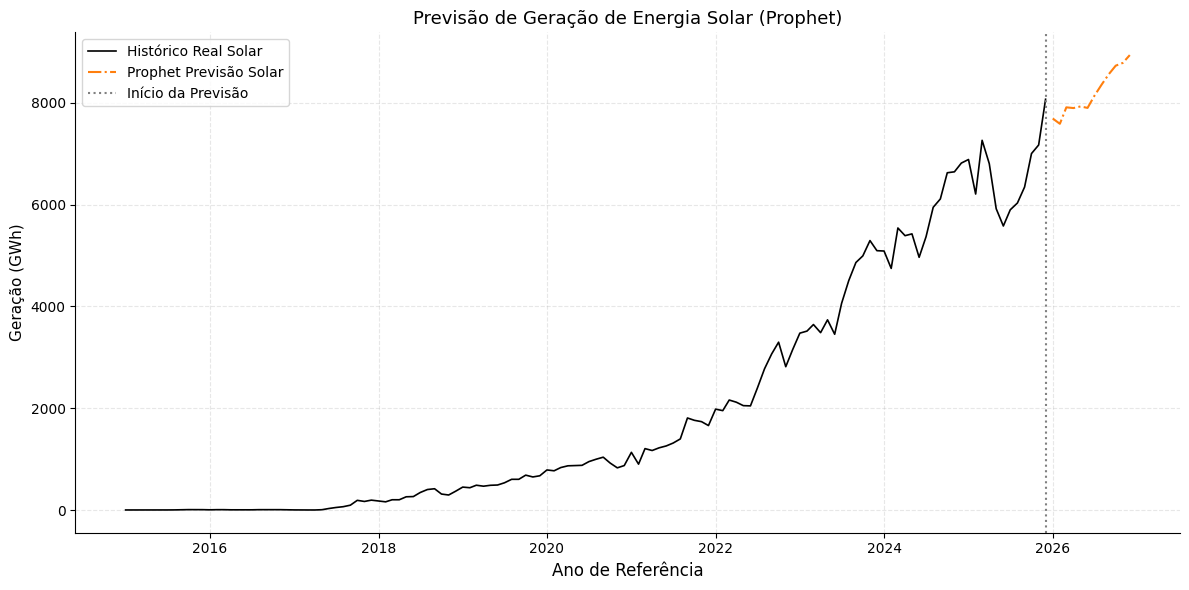

In [17]:

# Grafico Solar
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(serie_solar.index, serie_solar.values, label='Histórico Real Solar', color='black', linewidth=1.2)
ax.plot(p_futuro_solar['ds'], p_futuro_solar['yhat'], label='Prophet Previsão Solar', color='#ff7f0e', linestyle='-.')
ax.axvline(x=serie_solar.index[-1], color='gray', linestyle=':', linewidth=1.5, label='Início da Previsão')
ax.set_title('Previsão de Geração de Energia Solar (Prophet)', fontsize=13)
ax.set_ylabel('Geração (GWh)')
ax.set_xlabel('Ano de Referência', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

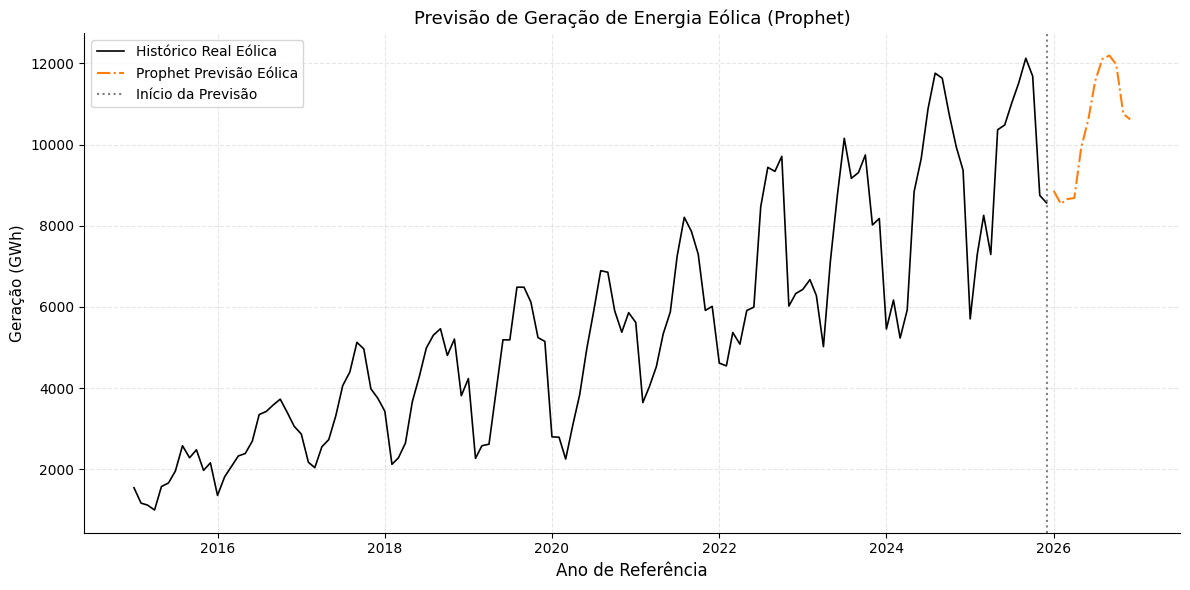

In [18]:
# Grafico Eólica
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(serie_wind.index, serie_wind.values, label='Histórico Real Eólica', color='black', linewidth=1.2)
ax.plot(p_futuro_wind['ds'], p_futuro_wind['yhat'], label='Prophet Previsão Eólica', color='#ff7f0e', linestyle='-.')
ax.axvline(x=serie_wind.index[-1], color='gray', linestyle=':', linewidth=1.5, label='Início da Previsão')
ax.set_title('Previsão de Geração de Energia Eólica (Prophet)', fontsize=13)
ax.set_ylabel('Geração (GWh)')
ax.set_xlabel('Ano de Referência', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()